# 10 — Extracción de parches satelitales y normalización

Esta notebook cierra el bloque de preparación de datos satelitales. Su propósito es resolver tres problemas concretos que `11-dataset_training.ipynb` necesita tener resueltos antes de construir el conjunto de entrenamiento.

**Qué resuelve**

**1. Mapeo estaciones → píxeles**
Cada estación IDEAM tiene coordenadas geográficas (lat, lon), y la grilla GOES tiene 198 × 199 píxeles con su propia resolución y cobertura espacial. Para cada una de las 63 estaciones con umbral operativo, esta notebook identifica el píxel más cercano de la grilla y verifica que un parche de 32×32 píxeles centrado en él quepa completamente dentro del dominio. El resultado es un archivo de mapeo que indica qué recortar de cada imagen para cada estación.

**2. Parámetros de normalización z-score**
Las cinco bandas del ABI operan en rangos de temperatura de brillo distintos (~237 K en C08 frente a ~273 K en C13), lo que sesgaría el aprendizaje de las capas convolucionales hacia las bandas de mayor magnitud y varianza. Para evitarlo, cada banda se normaliza restando su media y dividiendo por su desviación estándar. Los parámetros se calculan exclusivamente sobre una muestra de imágenes del período de entrenamiento (1 de enero a 14 de noviembre de 2024) y se aplican fijos a los tres conjuntos, de modo que ni la validación ni la prueba intervienen en su estimación. Como `09-goes_intercalibration.ipynb` no encontró diferencias de calibración que corregir entre GOES-16 y GOES-19, los mismos parámetros sirven para las imágenes de ambos satélites.

**3. Validación de la función de extracción**
Antes de que `extraer_parche()` se aplique a cientos de miles de pares, se valida visualmente sobre dos casos contrastantes: un instante de madrugada sin actividad convectiva y uno de la tarde con convección organizada sobre la Sabana.

**Por qué no se pre-extraen los parches**

Pre-extraer los parches de las 63 estaciones para los ~105.000 instantes del registro requeriría del orden de 68 GB aun conservando los valores enteros con que se almacena el producto CMIP, y el doble en precisión simple. En su lugar, esta notebook produce los insumos que permiten extraer los parches al vuelo durante la construcción del conjunto de datos, conservando únicamente los pares (estación, instante) que tienen tanto etiqueta válida como imagen satelital disponible.

**Outputs**

| Archivo | Contenido |
|---|---|
| `estaciones_pixels.csv` | 63 filas: estación → (fila, columna) en la grilla GOES |
| `normalizacion_zscore.csv` | 5 filas: banda → (media, desvío) del período de entrenamiento |
| `img-validacion_parches.png` | 3 estaciones × 5 bandas, instante de madrugada |
| `img-validacion_parches_convectivo.png` | 3 estaciones × 5 bandas, instante convectivo |

In [1]:
# Configuración --------------------------------------------------------------------
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from tqdm import tqdm

RUTA_BASE = Path(r"C:\Users\diani\Documents\repositories\nowcasting-bogota")
RUTA_SAT  = RUTA_BASE / "data_ingestion" / "satellite"
RUTA_GT   = RUTA_BASE / "data_ingestion" / "ground_truth"

INV_PATH  = RUTA_SAT / "inventario_goes.parquet"             # 08-goes-inventory
COEF_PATH = RUTA_SAT / "intercalibracion_coeficientes.csv"   # 09-goes-intercalibration
GT_PATH   = RUTA_GT / "estaciones_ground_truth.csv"
COO_PATH  = RUTA_GT / "estaciones_sabana_candidatas.csv"
UMB_PATH  = RUTA_GT / "umbral_operativo_por_estacion.csv"    # 63 estaciones con umbral

sys.path.append(str(RUTA_BASE / "src"))
from paleta import PALETA, ROL, aplicar_estilo
aplicar_estilo()

BANDAS        = ["CMI_C08", "CMI_C09", "CMI_C10", "CMI_C13", "CMI_C14"]
HALF_SIZE     = 16      # parche de 32×32 píxeles (~64×64 km)
N_MUESTRA     = 1000    # imágenes del período de entrenamiento para el z-score
SEED          = 42
FIN_TRAIN_UTC = pd.Timestamp("2024-11-15 05:00")   # 15-nov-2024 00:00 hora local: inicio de validación

# Estaciones: las 63 con umbral operativo, con sus coordenadas
gt     = pd.read_csv(GT_PATH)
coo    = pd.read_csv(COO_PATH)
umbral = pd.read_csv(UMB_PATH)
est = gt.merge(coo[["codigo", "latitud", "longitud"]], left_on="estacion", right_on="codigo", how="left")
est = est[est["estacion"].astype("int64").isin(umbral["codigoestacion"].astype("int64"))].reset_index(drop=True)
assert len(est) == len(umbral) == 63, f"Se esperaban 63 estaciones, hay {len(est)}"
assert est["latitud"].notna().all(), "Hay estaciones sin coordenadas"
print(f"Estaciones con umbral y coordenadas: {len(est)}")

# Inventario: solo imágenes utilizables
inv = pd.read_parquet(INV_PATH)
assert inv["timestamp"].dt.tz is None
utiles = inv[~inv["excluido_qc"]]
print(f"Inventario: {len(inv):,} instantes  |  utilizables: {len(utiles):,}")

# Intercalibración: 09 concluyó que no hay corrección
coef = pd.read_csv(COEF_PATH).set_index("banda")["offset_K"]
assert (coef == 0).all(), "09-goes_intercalibration exportó offsets no nulos: aplicarlos antes del z-score"

Estaciones con umbral y coordenadas: 63
Inventario: 104,973 instantes  |  utilizables: 104,745


In [3]:
# Grilla GOES: cargar lat/lon de referencia ----------------------------------------
# # Leer un archivo cualquiera para extraer la grilla lat/lon
filepath_ref = inv.iloc[0]["filepath"]
ds_ref = xr.open_dataset(filepath_ref)

lat_grid = ds_ref["lat"].values   # shape (198,)
lon_grid = ds_ref["lon"].values   # shape (199,)
ds_ref.close()

print(f"Grilla GOES:")
print(f"  lat: {lat_grid.min():.3f}° → {lat_grid.max():.3f}°  ({len(lat_grid)} píxeles)")
print(f"  lon: {lon_grid.min():.3f}° → {lon_grid.max():.3f}°  ({len(lon_grid)} píxeles)")
print(f"  Resolución aprox: {abs(np.diff(lat_grid).mean())*111:.2f} km/px")

Grilla GOES:
  lat: 2.802° → 6.391°  (198 píxeles)
  lon: -75.880° → -72.287°  (199 píxeles)
  Resolución aprox: 2.02 km/px


In [4]:
# Mapeo estaciones → píxeles -------------------------------------------------------
def encontrar_pixel(lat_est, lon_est, lat_grid, lon_grid):
    """Devuelve (fila, columna) del píxel más cercano a la estación."""
    fila = int(np.argmin(np.abs(lat_grid - lat_est)))
    col  = int(np.argmin(np.abs(lon_grid - lon_est)))
    return fila, col

def verificar_margen(fila, col, half_size, nrows, ncols):
    """Comprueba que el parche centrado en (fila, col) cabe en la grilla."""
    return (
        fila >= half_size and fila < nrows - half_size and
        col  >= half_size and col  < ncols - half_size
    )

nrows, ncols = len(lat_grid), len(lon_grid)
registros = []

for _, row in est.iterrows():
    fila, col = encontrar_pixel(row["latitud"], row["longitud"],
                                lat_grid, lon_grid)
    en_margen = verificar_margen(fila, col, HALF_SIZE, nrows, ncols)
    lat_px = lat_grid[fila]
    lon_px = lon_grid[col]
    dist_km = np.sqrt(
        ((row["latitud"]  - lat_px) * 111) ** 2 +
        ((row["longitud"] - lon_px) * 111 * np.cos(np.radians(row["latitud"]))) ** 2
    )
    registros.append({
        "codigoestacion": row["estacion"],
        "lat_est" : row["latitud"],
        "lon_est" : row["longitud"],
        "fila"    : fila,
        "col"     : col,
        "lat_px"  : lat_px,
        "lon_px"  : lon_px,
        "dist_km" : round(dist_km, 3),
        "en_margen": en_margen,
    })

df_pixels = pd.DataFrame(registros)

print(f"Estaciones mapeadas    : {len(df_pixels)}")
print(f"  Dentro del margen    : {df_pixels['en_margen'].sum()}")
print(f"  Fuera del margen     : {(~df_pixels['en_margen']).sum()}")
print(f"\nDistancia estación → píxel (km):")
print(df_pixels["dist_km"].describe().round(3))
print(f"\nEstaciones fuera del margen (si las hay):")
print(df_pixels[~df_pixels["en_margen"]][["codigoestacion","lat_est","lon_est"]])

Estaciones mapeadas    : 63
  Dentro del margen    : 63
  Fuera del margen     : 0

Distancia estación → píxel (km):
count    63.000
mean      0.760
std       0.268
min       0.106
25%       0.538
50%       0.785
75%       0.988
max       1.182
Name: dist_km, dtype: float64

Estaciones fuera del margen (si las hay):
Empty DataFrame
Columns: [codigoestacion, lat_est, lon_est]
Index: []


**Resultados del mapeo**

Las 63 estaciones se mapean a la grilla GOES y ninguna queda fuera del margen de extracción, lo que confirma que el dominio satelital cubre con holgura la red de observación. Con una resolución de 2.02 km por píxel, el parche de 32×32 píxeles ofrece alrededor de 64×64 km de contexto espacial en torno a cada estación, que es el campo visual del modelo en cada predicción.

La distancia entre cada estación y el centro de su píxel asignado tiene una mediana de 0.79 km y un máximo de 1.18 km, valores inferiores a la resolución del sensor. A este error de posicionamiento se suma el desplazamiento por paralaje de los topes de nube altos, de hasta 1.37 km sobre la Sabana según `06-parallax_quantification.ipynb`. Aun en el caso más desfavorable, la combinación de ambos efectos es del orden de un píxel, pequeña frente al campo de 64 km que ve el modelo, cuya predicción descansa en la estructura espacial del parche y no en el valor de un píxel aislado. Ninguno de los dos efectos requiere, por tanto, tratamiento adicional.

In [5]:
# Parámetros z-score (período de entrenamiento) -------------------------------------
train_img = utiles[utiles["timestamp"] < FIN_TRAIN_UTC]
muestra_z = train_img.sample(N_MUESTRA, random_state=SEED)
print(f"Imágenes utilizables del período de entrenamiento: {len(train_img):,}  |  muestra: {N_MUESTRA}")
print(f"Rango de la muestra: {muestra_z['timestamp'].min()} → {muestra_z['timestamp'].max()}")

acumulados = {b: [] for b in BANDAS}
for fp in tqdm(muestra_z["filepath"], desc="Calculando z-score"):
    with xr.open_dataset(fp) as ds:
        for b in BANDAS:
            v = ds[b].values.ravel()
            assert np.isfinite(v).all(), f"Píxeles sin dato en {fp} ({b})"
            acumulados[b].append(v)

df_zscore = pd.DataFrame([
    {"banda": b, "mean": round(float(np.concatenate(acumulados[b]).mean()), 4),
     "std": round(float(np.concatenate(acumulados[b]).std()), 4),
     "n_px": int(sum(a.size for a in acumulados[b]))}
    for b in BANDAS
])
print(df_zscore.to_string(index=False))

Imágenes utilizables del período de entrenamiento: 45,654  |  muestra: 1000
Rango de la muestra: 2024-01-01 00:40:00 → 2024-11-14 18:40:00


Calculando z-score: 100%|██████████| 1000/1000 [00:22<00:00, 44.91it/s]


  banda     mean     std     n_px
CMI_C08 236.5065  8.4390 39402000
CMI_C09 244.2719 10.5452 39402000
CMI_C10 251.7264 12.4196 39402000
CMI_C13 272.2148 20.7946 39402000
CMI_C14 270.8144 20.9851 39402000


La media de la temperatura de brillo crece desde las bandas de vapor de agua de nivel alto hacia las de ventana infrarroja, de 236.5 K en C08 a 272.2 K en C13, y lo mismo ocurre con su dispersión, que pasa de 8.4 K a 20.8 K. La mayor dispersión de las bandas de ventana refleja que observan tanto la superficie, cálida en las horas de sol, como los topes de nube, que en la convección profunda son los elementos más fríos de la escena; las bandas de vapor de agua, en cambio, observan capas de la troposfera cuya temperatura varía menos. Sin normalización, esas diferencias de escala harían que las bandas de ventana dominaran el aprendizaje.

In [12]:
# Contorno de referencia: área urbana continua de Bogotá ------------------------------
import geopandas as gpd

RUTA_BOG = RUTA_BASE / "data" / "cartografia" / "perimetro_urbano_bogota.geojson"   # perímetro urbano, POT (Decreto 555 de 2021)

assert lat_grid[0] > lat_grid[-1], "La fila 0 de la grilla no es el borde norte"
orden_lat = np.argsort(lat_grid)

def a_pixel(lon, lat):
    """lon/lat → (columna, fila) fraccionarias; NaN fuera del dominio."""
    col  = np.interp(lon, lon_grid, np.arange(len(lon_grid)), left=np.nan, right=np.nan)
    fila = np.interp(lat, lat_grid[orden_lat], np.arange(len(lat_grid))[orden_lat], left=np.nan, right=np.nan)
    return col, fila

def lineas_pixel(gdf):
    """Contorno exterior de cada polígono, en coordenadas de píxel."""
    lineas = []
    for geom in gdf.to_crs(4326).explode(index_parts=False).geometry:
        lon, lat = geom.exterior.xy
        lineas.append(a_pixel(np.asarray(lon), np.asarray(lat)))
    return lineas

# Solo el polígono continuo de la ciudad: se descartan los centros poblados sueltos
partes = gpd.read_file(RUTA_BOG).explode(index_parts=False).reset_index(drop=True)
ciudad = partes.loc[[partes.to_crs(3116).area.idxmax()]]
print(f"Polígonos en el perímetro: {len(partes)}  |  se conserva el mayor: "
      f"{ciudad.to_crs(3116).area.iloc[0] / 1e6:.0f} km²")

CONTORNOS = [(lineas_pixel(ciudad), PALETA["wi-purple"], 0.8)]

def dibujar_contornos(ax, fila0=0, col0=0):
    """Dibuja los contornos desplazados al origen (fila0, col0) del eje."""
    for lineas, color, lw in CONTORNOS:
        for c, f in lineas:
            ax.plot(c - col0, f - fila0, color=color, linewidth=lw)

Polígonos en el perímetro: 26  |  se conserva el mayor: 368 km²


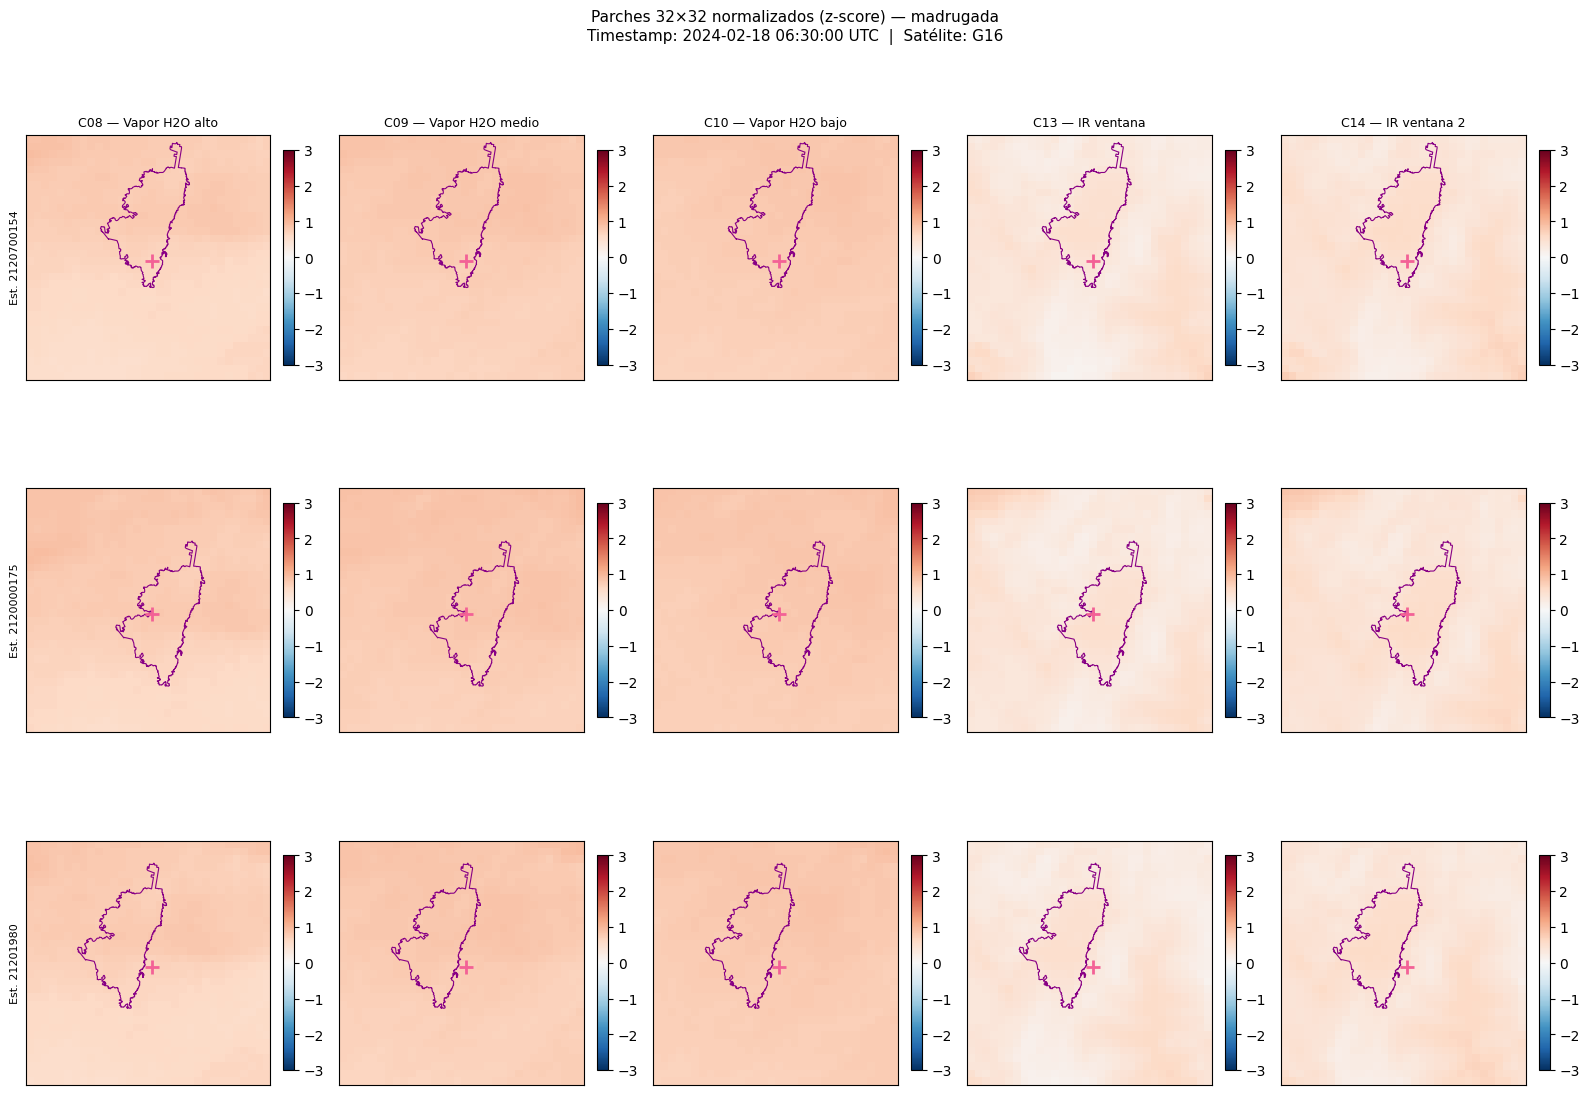

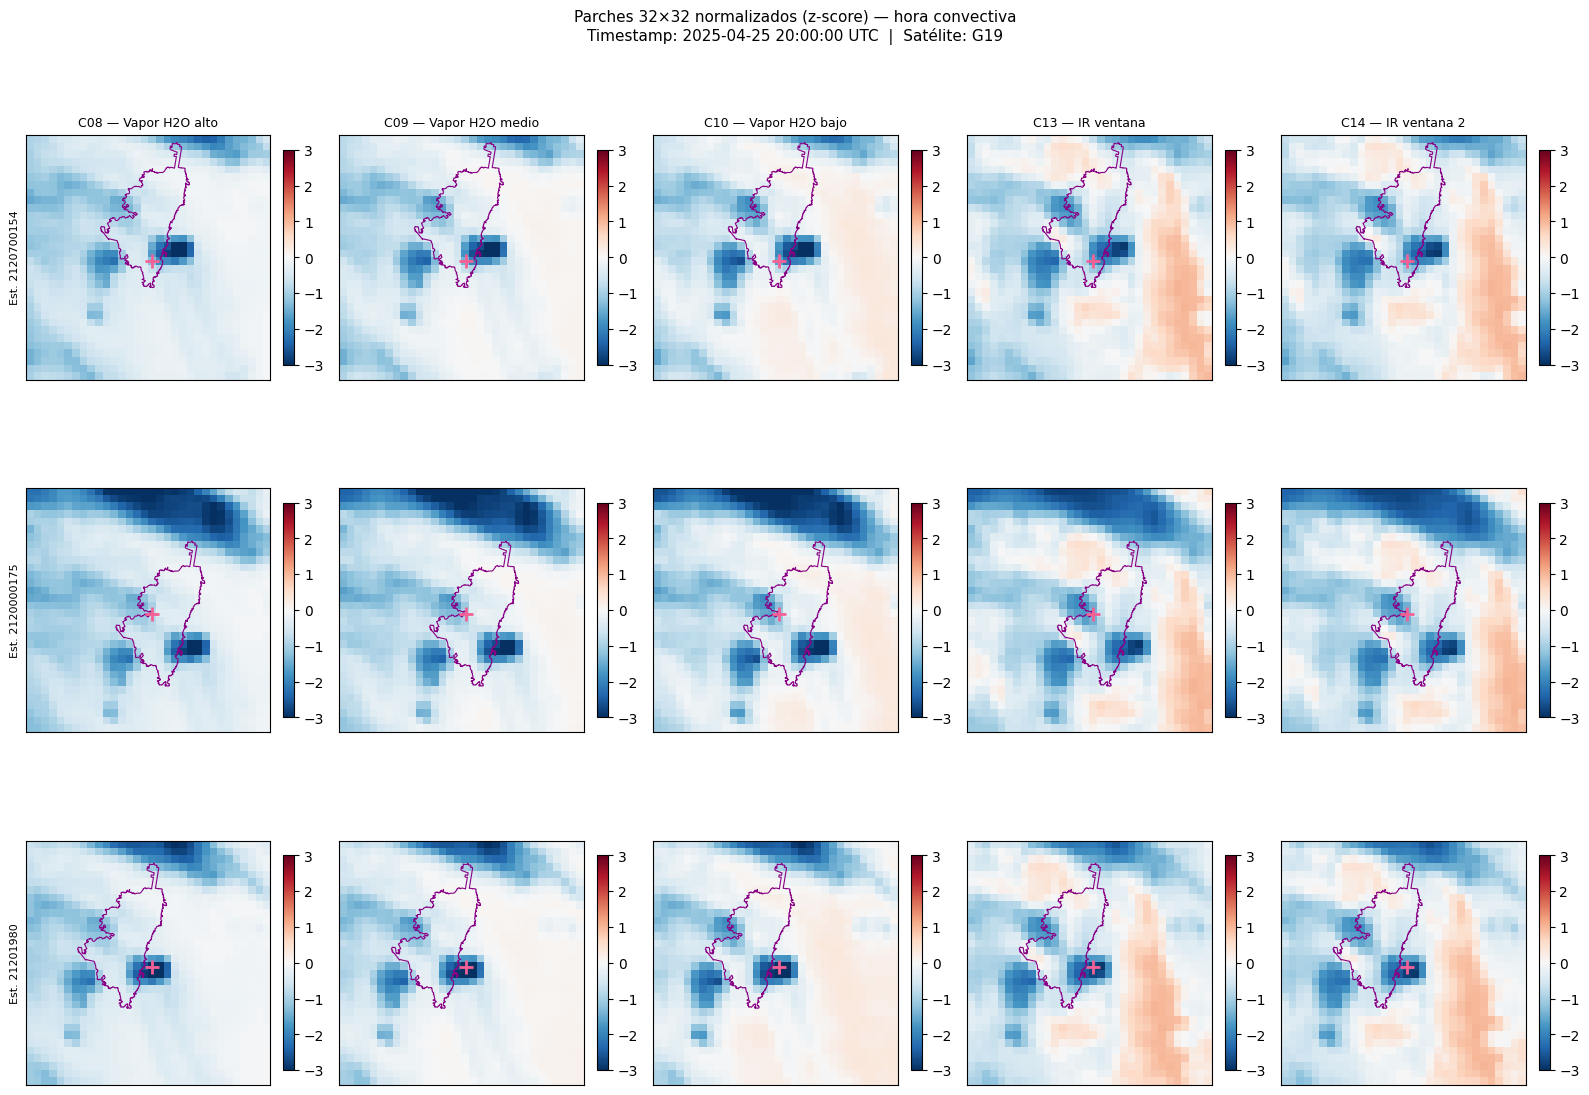

  madrugada: z-score min +0.08  max +0.94  | fracción |z| > 3: 0.000
 convectivo: z-score min -4.05  max +1.02  | fracción |z| > 3: 0.005


In [16]:
# Función de extracción y validación visual ----------------------------------------
def extraer_parche(filepath, fila_centro, col_centro, half_size, bandas, zscore_params):
    """Parche (B, 2·half_size, 2·half_size) centrado en (fila_centro, col_centro), normalizado por z-score."""
    f0, f1 = fila_centro - half_size, fila_centro + half_size
    c0, c1 = col_centro - half_size, col_centro + half_size
    with xr.open_dataset(filepath) as ds:
        parche = np.stack([ds[b].values[f0:f1, c0:c1] for b in bandas], axis=0).astype(np.float32)
    assert np.isfinite(parche).all(), f"Parche con píxeles sin dato: {filepath}"
    params = zscore_params.set_index("banda").loc[bandas]
    return (parche - params["mean"].values[:, None, None]) / params["std"].values[:, None, None]


def fila_inventario(ts):
    fila = utiles[utiles["timestamp"] == ts]
    assert len(fila) == 1, f"{ts} no tiene imagen utilizable"
    return fila.iloc[0]


TITULOS_BANDA = {"CMI_C08": "C08 — Vapor H2O alto", "CMI_C09": "C09 — Vapor H2O medio",
                 "CMI_C10": "C10 — Vapor H2O bajo", "CMI_C13": "C13 — IR ventana",
                 "CMI_C14": "C14 — IR ventana 2"}

def figura_parches(fila_inv, est_muestra, titulo, archivo):
    """Figura estaciones × bandas; devuelve los parches para verificación numérica."""
    parches = []
    fig, axes = plt.subplots(len(est_muestra), len(BANDAS), figsize=(16, 4 * len(est_muestra)))
    for i, (_, e) in enumerate(est_muestra.iterrows()):
        p = extraer_parche(fila_inv["filepath"], int(e["fila"]), int(e["col"]), HALF_SIZE, BANDAS, df_zscore)
        parches.append(p)
        for j, b in enumerate(BANDAS):
            ax = axes[i][j]
            im = ax.imshow(p[j], cmap="RdBu_r", vmin=-3, vmax=3)
            dibujar_contornos(ax, int(e["fila"]) - HALF_SIZE, int(e["col"]) - HALF_SIZE)
            ax.set_xlim(-0.5, 2 * HALF_SIZE - 0.5)
            ax.set_ylim(2 * HALF_SIZE - 0.5, -0.5)
            if i == 0:
                ax.set_title(TITULOS_BANDA[b], fontsize=9)
            if j == 0:
                ax.set_ylabel(f"Est. {e['codigoestacion']}", fontsize=8)
            ax.set_xticks([]); ax.set_yticks([])
            ax.plot(HALF_SIZE, HALF_SIZE, "+", color=PALETA["wi-pink"], markersize=10, markeredgewidth=2)
            plt.colorbar(im, ax=ax, fraction=0.04)
    fig.suptitle(f"{titulo}\nTimestamp: {fila_inv['timestamp']} UTC  |  Satélite: {fila_inv['satelite']}", fontsize=11)
    plt.tight_layout()
    plt.savefig(RUTA_SAT / archivo, dpi=150, bbox_inches="tight")
    plt.show()
    return np.stack(parches)


est_muestra = df_pixels.sample(3, random_state=SEED)
TS_CALMA      = pd.Timestamp("2024-02-18 06:30")   # 01:30 hora local
TS_CONVECTIVO = pd.Timestamp("2025-04-25 20:00")   # 15:00 hora local

p_calma = figura_parches(fila_inventario(TS_CALMA), est_muestra,
                         "Parches 32×32 normalizados (z-score) — madrugada", "img-validacion_parches.png")
p_conv  = figura_parches(fila_inventario(TS_CONVECTIVO), est_muestra,
                         "Parches 32×32 normalizados (z-score) — hora convectiva", "img-validacion_parches_convectivo.png")

for nombre, p in [("madrugada", p_calma), ("convectivo", p_conv)]:
    print(f"{nombre:>11}: z-score min {p.min():+.2f}  max {p.max():+.2f}  "
          f"| fracción |z| > 3: {(np.abs(p) > 3).mean():.3f}")

**Validación visual — interpretación**

Los dos instantes de prueba ilustran los extremos del espacio de señales que el modelo debe aprender a distinguir.

**Madrugada (18 de febrero de 2024, 06:30 UTC; 01:30 hora local, GOES-16).** Las cinco bandas muestran valores positivos y uniformes, entre +0.08 y +0.94 desvíos, sin estructura espacial apreciable. Las bandas de vapor de agua, más cálidas que su media, indican una troposfera media y alta relativamente seca, y las de ventana infrarroja, cercanas a su media, corresponden a una superficie enfriada por la noche y libre de nubosidad alta. Es una escena sin convección en plena temporada seca, representativa de la gran mayoría de los casos negativos del conjunto de datos.

**Hora convectiva (25 de abril de 2025, 20:00 UTC; 15:00 hora local, GOES-19).** El instante coincide con el pico de la convección sobre la Sabana, que Casallas-García et al. (2023) sitúan a inicios de la tarde, y el contraste con el caso anterior es inmediato. Aparecen celdas compactas de pocos píxeles con valores por debajo de −3 desvíos (el mínimo es −4.05), junto con un sistema nuboso más extenso en el borde norte de dos de los parches. Estas estructuras aparecen en la misma posición en las cinco bandas: los topes de las nubes convectivas alcanzan niveles lo bastante altos como para dominar también la señal de las bandas de vapor de agua, que en esos píxeles observan la nube y no la humedad de la atmósfera circundante. Fuera de las celdas, las bandas de ventana infrarroja muestran una franja cálida hacia el este, correspondiente a superficie calentada por el sol entre la nubosidad, que las bandas de vapor de agua no registran porque no son sensibles a la superficie.

La validación confirma dos propiedades de la extracción. La primera es su coherencia geográfica: las tres estaciones observan la misma escena, y las celdas se desplazan de un parche a otro según la posición relativa de cada estación, de modo que una de ellas queda sobre una celda activa, otra en su borde y la tercera entre celdas. La segunda es la escala de la normalización: los valores típicos quedan dentro de ±3 desvíos, y solo los topes convectivos más fríos se alejan de ese rango (0.5% de los píxeles del caso convectivo), precisamente la señal de interés, que la normalización conserva sin recortar.

In [19]:
# Etiquetas en torno al instante convectivo -------------------------------------------
RUTA_ETIQ = RUTA_BASE / "data_ingestion" / "ground_truth" / "etiquetas_ground_truth_v2.parquet"
etiq = pd.read_parquet(RUTA_ETIQ)
print(etiq.dtypes.to_string(), "\ntz:", etiq["timestamp"].dt.tz)

t_utc   = TS_CONVECTIVO.tz_localize("UTC")
codigos = est_muestra["codigoestacion"].astype("int64")

en_t = etiq[etiq["timestamp"] == t_utc]
print(f"\nEn {t_utc}: {en_t['etiqueta'].notna().sum()} estaciones con etiqueta válida, "
      f"{(en_t['etiqueta'] == 1).sum()} positivas")

cerca = etiq[etiq["timestamp"].between(t_utc - pd.Timedelta("2h"), t_utc + pd.Timedelta("2h"))
             & etiq["codigoestacion"].astype("int64").isin(codigos)]
display(cerca.pivot(index="timestamp", columns="codigoestacion", values="etiqueta"))

codigoestacion                 object
timestamp         datetime64[ns, UTC]
etiqueta                      float64 
tz: UTC

En 2025-04-25 20:00:00+00:00: 63 estaciones con etiqueta válida, 23 positivas


codigoestacion,0021201980,2120000175,2120700154
timestamp,,,
2025-04-25 18:00:00+00:00,1.0,0.0,0.0
2025-04-25 18:10:00+00:00,1.0,0.0,0.0
2025-04-25 18:20:00+00:00,1.0,0.0,0.0
2025-04-25 18:30:00+00:00,1.0,0.0,0.0
2025-04-25 18:40:00+00:00,1.0,0.0,0.0
2025-04-25 18:50:00+00:00,1.0,0.0,0.0
2025-04-25 19:00:00+00:00,1.0,0.0,0.0
2025-04-25 19:10:00+00:00,1.0,0.0,0.0
2025-04-25 19:20:00+00:00,1.0,0.0,0.0


Las etiquetas del instante convectivo confirman la correspondencia entre la escena y el ground truth. Se trata de un evento extendido, con etiqueta positiva en 23 de las 63 estaciones. De las tres estaciones de la figura, la que se encuentra bajo una celda activa tiene etiqueta positiva, mientras que las otras dos, situadas en el borde de una celda y entre celdas, tienen etiqueta negativa. La secuencia de etiquetas de la estación positiva sitúa su lluvia fuerte aproximadamente entre las 20:00 y las 21:30 UTC, bajo la misma celda que la imagen de las 20:00 muestra sobre ella.

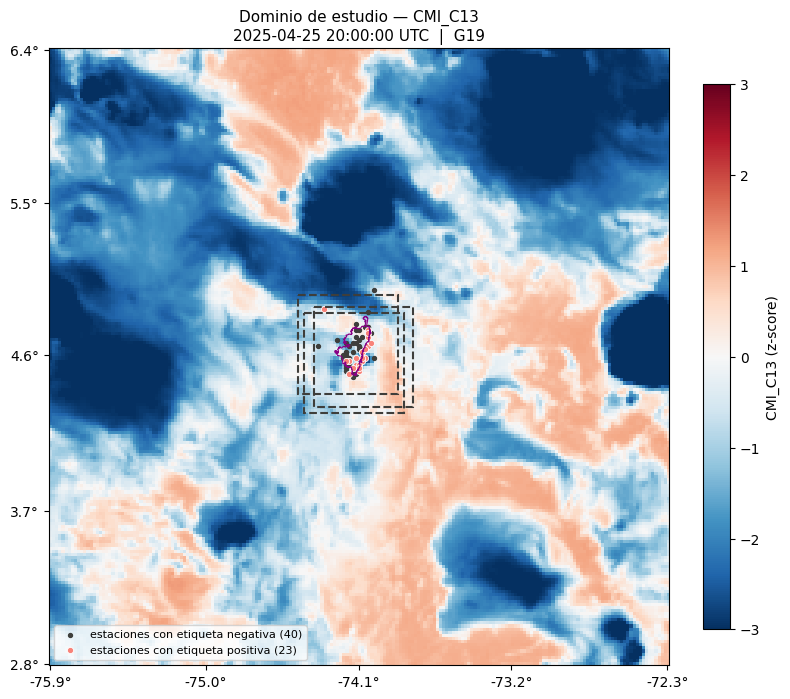

In [28]:
# Dominio completo en el instante convectivo -----------------------------------------
def figura_dominio(fila_inv, est_muestra, codigos_pos, banda="CMI_C13", archivo="img-validacion_dominio_convectivo.png"):
    p = df_zscore.set_index("banda").loc[banda]
    with xr.open_dataset(fila_inv["filepath"]) as ds:
        z = (ds[banda].values - p["mean"]) / p["std"]

    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(z, cmap="RdBu_r", vmin=-3, vmax=3)
    dibujar_contornos(ax)
    pos = df_pixels["codigoestacion"].astype("int64").isin(codigos_pos)
    ax.scatter(df_pixels.loc[~pos, "col"], df_pixels.loc[~pos, "fila"], s=8,
               color=ROL["linea_ref"], label=f"estaciones con etiqueta negativa ({(~pos).sum()})")
    ax.scatter(df_pixels.loc[pos, "col"], df_pixels.loc[pos, "fila"], s=20,
               color=ROL["umbral"], edgecolors="white", linewidths=0.6,
               label=f"estaciones con etiqueta positiva ({pos.sum()})")
    #ax.scatter(df_pixels["col"], df_pixels["fila"], s=8, color=ROL["linea_ref"], label="estaciones")
    for _, e in est_muestra.iterrows():
        ax.add_patch(plt.Rectangle((e["col"] - HALF_SIZE - 0.5, e["fila"] - HALF_SIZE - 0.5),
                                   2 * HALF_SIZE, 2 * HALF_SIZE, fill=False,
                                   edgecolor=ROL["linea_ref"], linewidth=1.5, linestyle="--"))
    ax.set_xlim(-0.5, z.shape[1] - 0.5)
    ax.set_ylim(z.shape[0] - 0.5, -0.5)
    xt = np.linspace(0, len(lon_grid) - 1, 5).round().astype(int)
    yt = np.linspace(0, len(lat_grid) - 1, 5).round().astype(int)
    ax.set_xticks(xt, [f"{lon_grid[i]:.1f}°" for i in xt])
    ax.set_yticks(yt, [f"{lat_grid[i]:.1f}°" for i in yt])
    plt.colorbar(im, ax=ax, fraction=0.04, label=f"{banda} (z-score)")
    ax.set_title(f"Dominio de estudio — {banda}\n{fila_inv['timestamp']} UTC  |  {fila_inv['satelite']}", fontsize=11)
    ax.legend(loc="lower left", fontsize=8)
    plt.tight_layout()
    plt.savefig(RUTA_SAT / archivo, dpi=150, bbox_inches="tight")
    plt.show()

codigos_pos = en_t.loc[en_t["etiqueta"] == 1, "codigoestacion"].astype("int64")
figura_dominio(fila_inventario(TS_CONVECTIVO), est_muestra, codigos_pos)

La figura del dominio completo ubica los tres parches dentro de la escena del instante convectivo. Los parches se superponen en torno a Bogotá, donde se concentra la red de estaciones, y cubren una fracción reducida del dominio de ~400×400 km. En el mismo instante hay sistemas convectivos extensos en el valle del Magdalena, al noroeste, y hacia los Llanos Orientales, al sureste, que quedan fuera del campo visual de 64 km que ve el modelo en cada predicción.

In [7]:
# Exportación ----------------------------------------------------------------------
# Guardar solo estaciones dentro del margen
df_pixels_final = df_pixels[df_pixels["en_margen"]].copy()

px_path     = RUTA_SAT / "estaciones_pixels.csv"
zscore_path = RUTA_SAT / "normalizacion_zscore.csv"

df_pixels_final.to_csv(px_path,     index=False)
df_zscore.to_csv(zscore_path,        index=False)

print(f"Estaciones mapeadas exportadas : {px_path}  ({len(df_pixels_final)} filas)")
print(f"Parámetros z-score exportados  : {zscore_path}  ({len(df_zscore)} bandas)")
print(f"\nResumen:")
print(f"  Parche: {2*HALF_SIZE}×{2*HALF_SIZE} px  (~{2*HALF_SIZE*2:.0f}×{2*HALF_SIZE*2:.0f} km)")
print(f"  Bandas: {BANDAS}")
print(f"  Z-score calculado sobre: {N_MUESTRA} imágenes del período de entrenamiento (1-ene a 14-nov-2024)")
print(f"  Offset de intercalibración: cero en las cinco bandas (09-goes-intercalibration)")

Estaciones mapeadas exportadas : C:\Users\diani\Documents\repositories\nowcasting-bogota\data_ingestion\satellite\estaciones_pixels.csv  (63 filas)
Parámetros z-score exportados  : C:\Users\diani\Documents\repositories\nowcasting-bogota\data_ingestion\satellite\normalizacion_zscore.csv  (5 bandas)

Resumen:
  Parche: 32×32 px  (~64×64 km)
  Bandas: ['CMI_C08', 'CMI_C09', 'CMI_C10', 'CMI_C13', 'CMI_C14']
  Z-score calculado sobre: 1000 imágenes del período de entrenamiento (1-ene a 14-nov-2024)
  Offset de intercalibración: cero en las cinco bandas (09-goes-intercalibration)


La muestra se toma al azar entre las imágenes utilizables del período de entrenamiento, es decir, las que superaron el control de calidad de `07-goes_qc.ipynb`. Ninguna de las imágenes muestreadas contiene píxeles sin dato: el control de calidad excluyó todos los archivos con alguna banda ausente, vacía o parcial, y los que se conservan están completos. La función de extracción mantiene de todos modos una verificación explícita, de modo que un parche con valores faltantes interrumpe el proceso en lugar de propagarse al entrenamiento.